In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving heart_failure_clinical_records_dataset.csv to heart_failure_clinical_records_dataset.csv


In [ ]:
df = pd.read_csv("heart_failure_clinical_records_dataset.csv")

print("Dataset loaded successfully!")
print("\nFirst 5 rows:")
display(df.head())

Dataset loaded successfully!

First 5 rows:


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 299
Number of columns: 13


In [ ]:
print("Dataset Shape:")
print(df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape:
(299, 13)

Data Types:
age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object

Missing Values:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


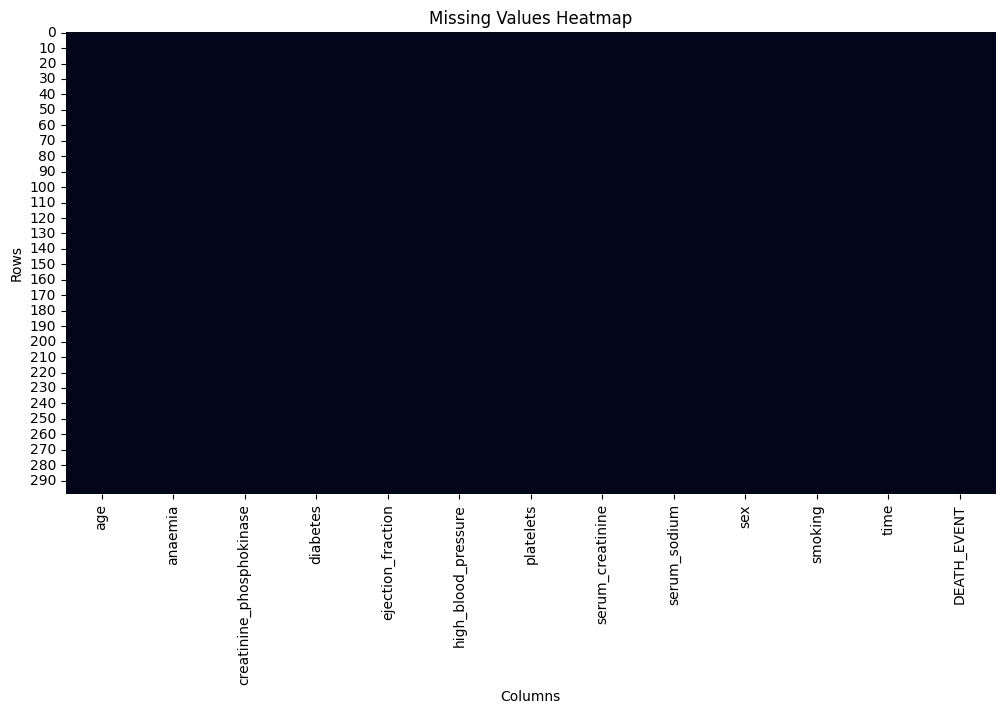

In [ ]:
plt.figure(figsize=(12, 6))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")

plt.show()

In [ ]:
# Make a copy of the original dataset
df_missing = df.copy()

# Randomly add missing values
np.random.seed(42)

# Add 5% missing values to selected columns
columns_to_add_missing = [
    "age",
    "ejection_fraction",
    "serum_creatinine",
    "platelets",
    "smoking"
]

for column in columns_to_add_missing:
    missing_indices = np.random.choice(
        df_missing.index,
        size=int(0.05 * len(df_missing)),
        replace=False
    )

    df_missing.loc[missing_indices, column] = np.nan

# Use this as our dataset from now on
df = df_missing

print("Missing values added successfully!")

Missing values added successfully!


In [ ]:
print(df.isnull().sum())

age                         14
anaemia                      0
creatinine_phosphokinase     0
diabetes                     0
ejection_fraction           14
high_blood_pressure          0
platelets                   14
serum_creatinine            14
serum_sodium                 0
sex                          0
smoking                     14
time                         0
DEATH_EVENT                  0
dtype: int64


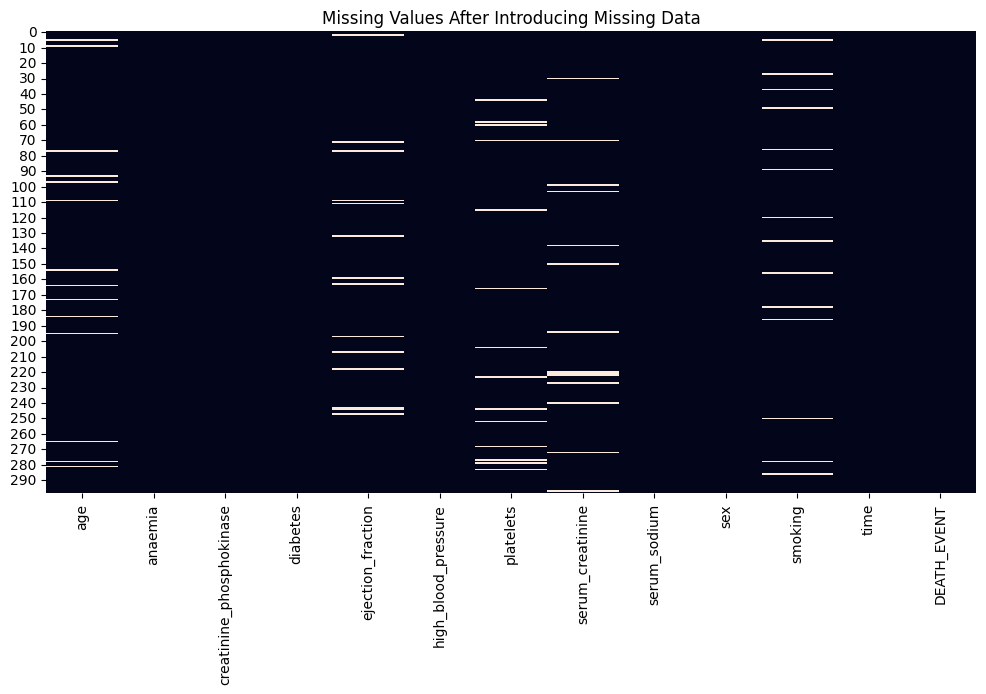

In [ ]:
plt.figure(figsize=(12, 6))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values After Introducing Missing Data")
plt.show()

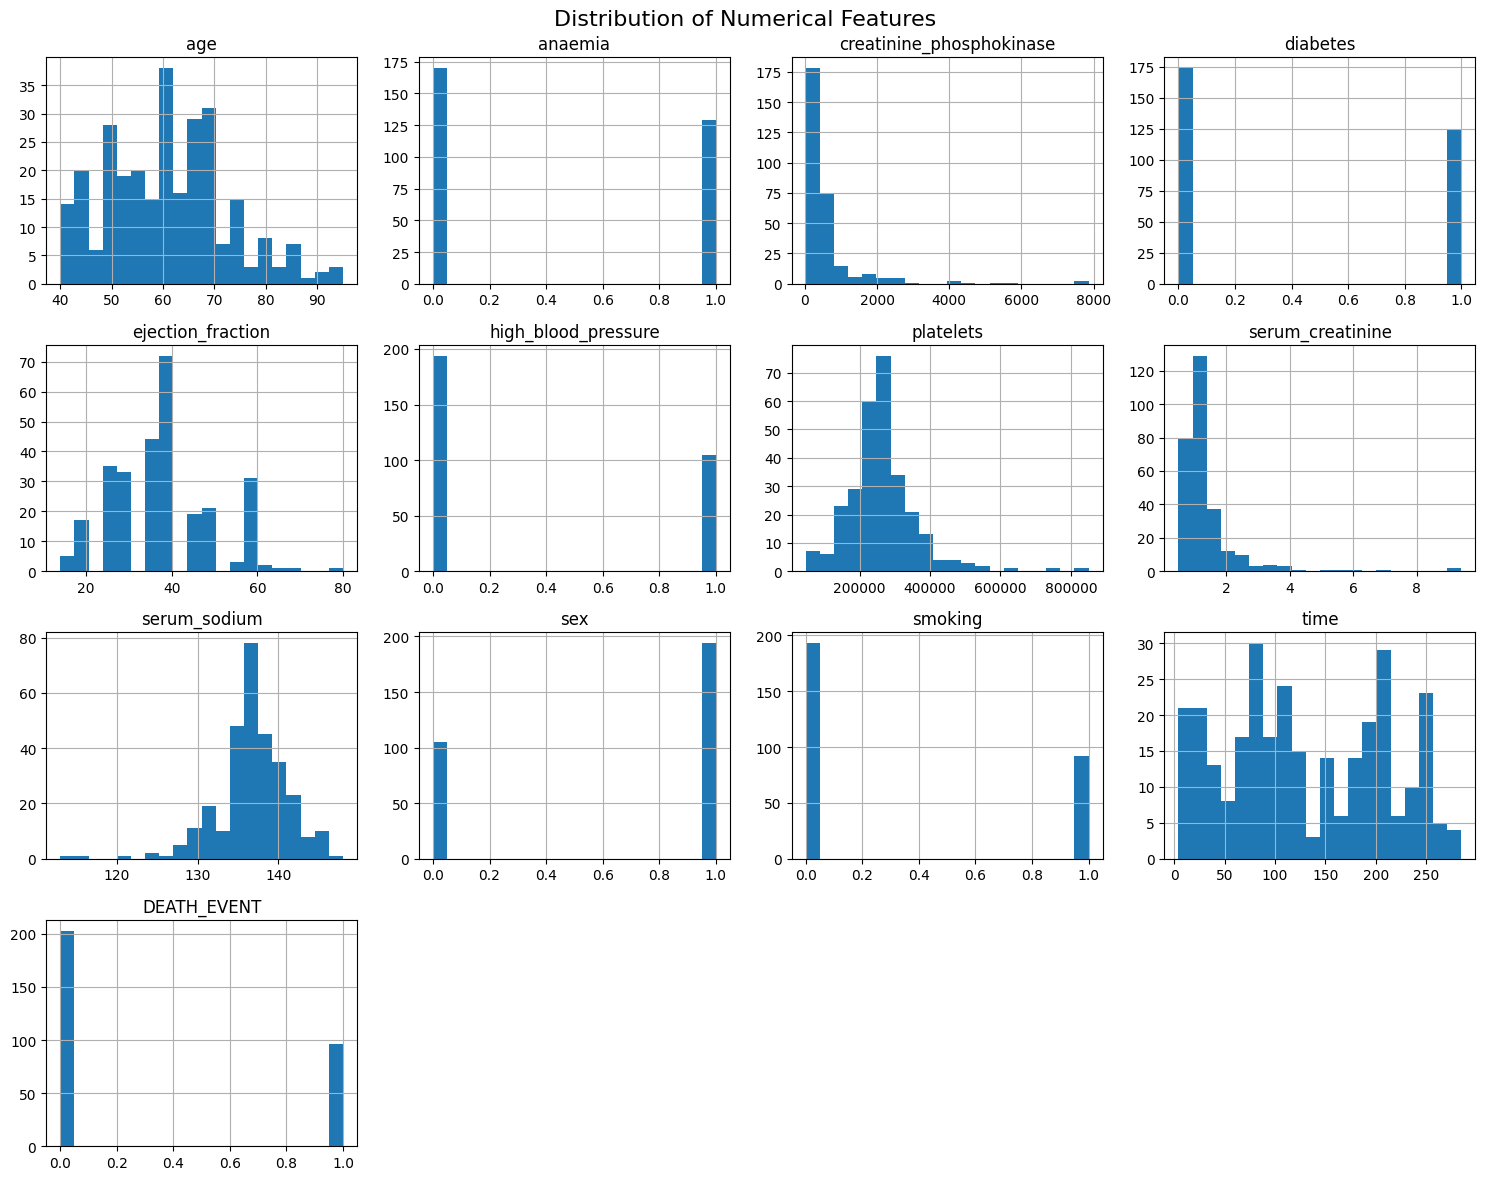

In [ ]:
# Select numerical columns
numerical_columns = df.select_dtypes(include=np.number).columns

# Plot histograms
df[numerical_columns].hist(
    figsize=(15, 12),
    bins=20
)

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

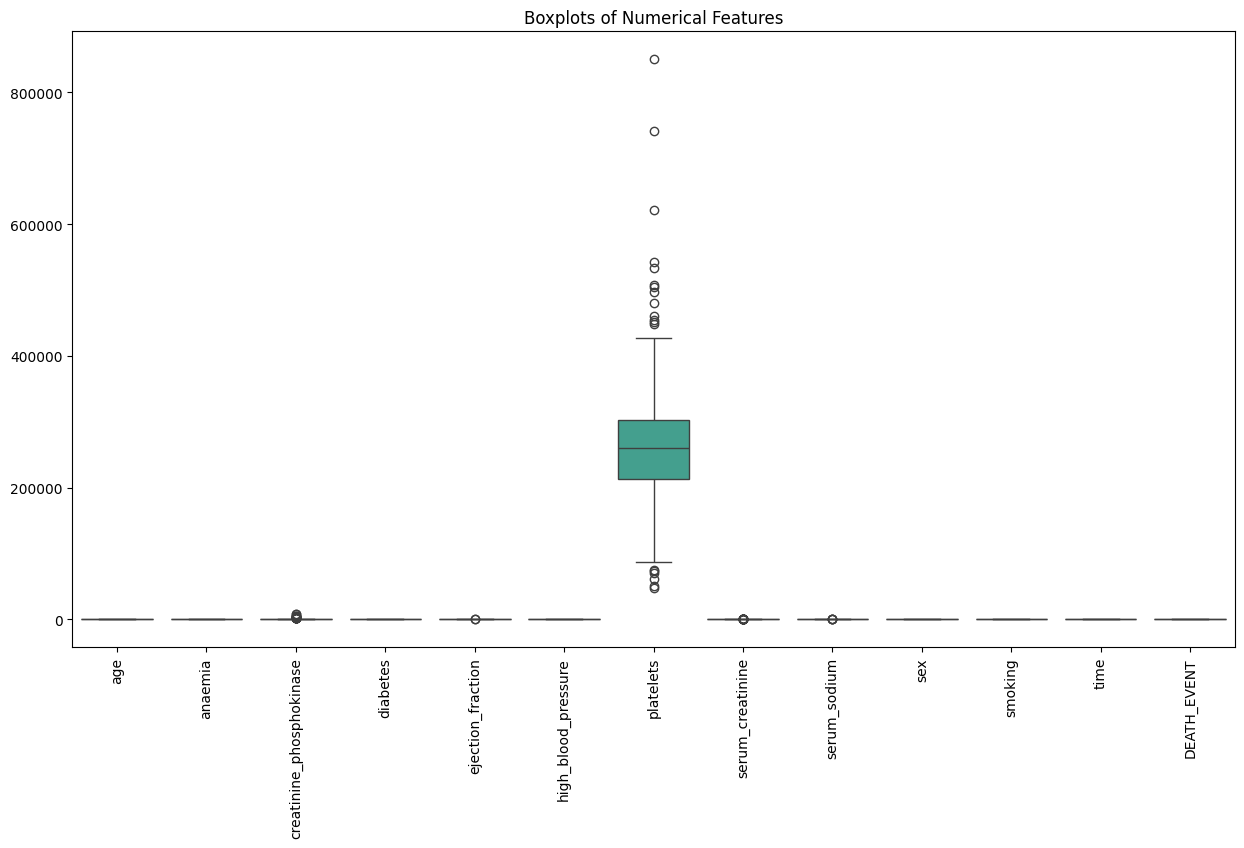

In [ ]:
plt.figure(figsize=(15, 8))

sns.boxplot(
    data=df[numerical_columns]
)

plt.title("Boxplots of Numerical Features")
plt.xticks(rotation=90)
plt.show()

In [ ]:
# Find numerical columns
numerical_columns = df.select_dtypes(include=np.number).columns

# Fill missing numerical values with median
for column in numerical_columns:
    df[column] = df[column].fillna(df[column].median())

print("Numerical missing values imputed using median.")

Numerical missing values imputed using median.


In [ ]:
categorical_columns = df.select_dtypes(include="object").columns

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
Index([], dtype='object')


In [ ]:
for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

print("Categorical missing values imputed using mode.")

Categorical missing values imputed using mode.


In [ ]:
df["smoking"] = df["smoking"].fillna(df["smoking"].mode()[0])

In [ ]:
print(df.isnull().sum())

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


In [ ]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [ ]:
# Select numerical columns
numerical_columns = df.select_dtypes(include=np.number).columns

print("Shape before removing outliers:", df.shape)

# Remove outliers using IQR
for column in numerical_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[
        (df[column] >= lower_bound) &
        (df[column] <= upper_bound)
    ]

print("Shape after removing outliers:", df.shape)

Shape before removing outliers: (299, 13)
Shape after removing outliers: (225, 13)


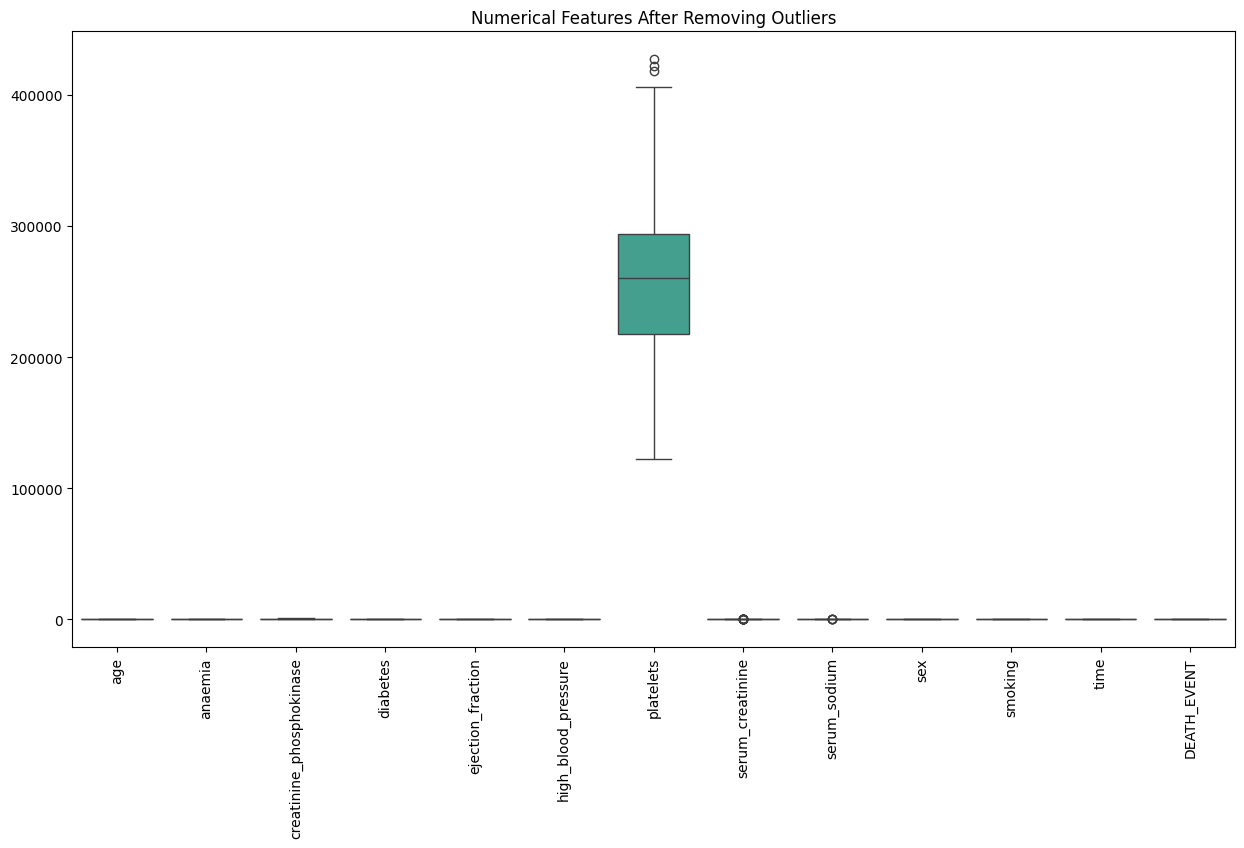

In [ ]:
plt.figure(figsize=(15, 8))

sns.boxplot(data=df[numerical_columns])

plt.title("Numerical Features After Removing Outliers")
plt.xticks(rotation=90)

plt.show()

